# **Vorhersage von Kundenzufriedenheit**

## Ziel:
ist es mit dem gegebenen Datensatz die Zufriedenheit der Kunden vorauszusagen und dabei wichtige Attribute herauszufinden.

### Datensatz: 
Der Satensatz wurde von der Online-Learnplattform DataCamp bereitgestellt, um Methoden und Fertigkeiten aus dem Bereich Data Science praktisch anzuwenden.

### Probelemtyp:
Es handelt sich um ein überwachtes lernendes Klassifikationsproblem, da die Zielvariable "Satisfaction" vorhersagt werden soll.



In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## **Setup**

In [74]:
airlines = pd.read_csv("airlines_final.csv")

## **Data Understanding**

In [75]:
airlines.head(15)

,Unnamed: 0,id,day,airline,destination,dest_region,dest_size,boarding_area,dept_time,wait_min,cleanliness,safety,satisfaction
0,0,1351,Tuesday,UNITED INTL,KANSAI,Asia,Hub,Gates 91-102,2018-12-31,115.0,Clean,Neutral,Very satisfied
1,1,373,Friday,ALASKA,SAN JOSE DEL CABO,Canada/Mexico,Small,Gates 50-59,2018-12-31,135.0,Clean,Very safe,Very satisfied
2,2,2820,Thursday,DELTA,LOS ANGELES,West US,Hub,Gates 40-48,2018-12-31,70.0,Average,Somewhat safe,Neutral
3,3,1157,Tuesday,SOUTHWEST,LOS ANGELES,West US,Hub,Gates 20-39,2018-12-31,190.0,Clean,Very safe,Somewhat satsified
4,4,2992,Wednesday,AMERICAN,MIAMI,East US,Hub,Gates 50-59,2018-12-31,559.0,Somewhat clean,Very safe,Somewhat satsified
5,5,634,Thursday,ALASKA,NEWARK,East US,Hub,Gates 50-59,2018-12-31,140.0,Somewhat clean,Very safe,Very satisfied
6,6,2578,Saturday,JETBLUE,LONG BEACH,West US,Small,Gates 1-12,2018-12-31,63.0,Clean,Very safe,Somewhat satsified
7,8,2592,Saturday,AEROMEXICO,MEXICO CITY,Canada/Mexico,Hub,Gates 1-12,2018-12-31,215.0,Somewhat clean,Very safe,Neutral
8,9,919,Friday,AIR CANADA,TORONTO,Canada/Mexico,Hub,Gates 91-102,2018-12-31,70.0,Somewhat clean,Somewhat safe,Somewhat satsified
9,10,3028,Tuesday,UNITED,PORTLAND,West US,Medium,Gates 70-90,2018-12-31,180.0,Average,Very safe,Neutral


In [76]:
airlines.describe()

,Unnamed: 0,id,wait_min
count,2477.000000,2477.000000,2477.000000
mean,1411.785224,1813.363746,166.084376
std,815.300508,945.226305,107.643625
min,0.000000,1.000000,15.000000
25%,709.000000,1038.000000,105.000000
50%,1414.000000,1859.000000,145.000000
75%,2122.000000,2581.000000,185.000000
max,2808.000000,9004.000000,1365.000000


In [77]:
print(airlines.info())

<class 'pandas.DataFrame'>
RangeIndex: 2477 entries, 0 to 2476
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     2477 non-null   int64  
 1   id             2477 non-null   int64  
 2   day            2477 non-null   str    
 3   airline        2477 non-null   str    
 4   destination    2477 non-null   str    
 5   dest_region    2477 non-null   str    
 6   dest_size      2477 non-null   str    
 7   boarding_area  2477 non-null   str    
 8   dept_time      2477 non-null   str    
 9   wait_min       2477 non-null   float64
 10  cleanliness    2477 non-null   str    
 11  safety         2477 non-null   str    
 12  satisfaction   2477 non-null   str    
dtypes: float64(1), int64(2), str(10)
memory usage: 251.7 KB
None


Für die spätere Datenvorbereitung ist es wichtig, die Skalenniveaus der einzelnen Merkmalen zu bestimmen, die diese Einfluss auf die Auswahl geeignerter Vorverarbeitungs- und Modellierungsmethoden haben.


| Attribut       | Beschreibung                              | Skalenniveau |
|----------------|--------------------------------------------|--------------|
| ID             | Eindeutige Identifikationsnummer           | Nominal      |
| Day            | Wochentag des Fluges                       | Nominal      |
| Airline        | Fluggesellschaft                           | Nominal      |
| Destination    | Zielflughafen / Zielstadt                  | Nominal      |
| Dest_Region    | Region des Zielflughafens                  | Nominal      |
| Dest_Size      | Größe des Zielflughafens                   | Ordinal      |
| Boarding Area  | Zugewiesener Boarding-Bereich              | Nominal      |
| dept_time      | Wartezeit in Minuten                       | Intervall    |
| Wait_min       | Wartezeit in Minuten                       | Verhältnis   |
| Cleanliness    | Bewertung der Sauberkeit (Skala)           | Ordinal      |
| Safety         | Bewertung des Sicherheitsgefühls (Skala)   | Ordinal      |
| Satisfaction   | Gesamtzufriedenheit (Skala)                | Ordinal      |

In [78]:
airlines['satisfaction'].value_counts()

satisfaction
Somewhat satsified      1349
Very satisfied           596
Neutral                  486
Somewhat unsatisfied      42
Very unsatisfied           4
Name: count, dtype: int64

Es ist erkennbar, dass ein Klassenungleichgewicht vorliegt. Dies sollte bei der Modellierung berücksichtigt werden.

## **Data Preparation**


### Fehlende Werte

In [79]:
print(airlines.isna().sum())

Unnamed: 0       0
id               0
day              0
airline          0
destination      0
dest_region      0
dest_size        0
boarding_area    0
dept_time        0
wait_min         0
cleanliness      0
safety           0
satisfaction     0
dtype: int64


### Inkonsistente Kategorien
In einigen kategorialen Merkmalen liegen inkonsistente Schreibweisen derselben Kategorien vor.

In [80]:
for i in range(len(airlines.columns)):
  print(airlines.iloc[:,i].unique(), "\n")

[   0    1    2 ... 2806 2807 2808] 

[1351  373 2820 ... 2684 2549 2162] 

<StringArray>
['Tuesday', 'Friday', 'Thursday', 'Wednesday', 'Saturday', 'Sunday', 'Monday']
Length: 7, dtype: str 

<StringArray>
[        'UNITED INTL',              'ALASKA',               'DELTA',
           'SOUTHWEST',            'AMERICAN',             'JETBLUE',
          'AEROMEXICO',          'AIR CANADA',              'UNITED',
            'INTERJET',    'TURKISH AIRLINES',      'AIR FRANCE/KLM',
        'HAWAIIAN AIR',                'COPA',                 'WOW',
          'KOREAN AIR',            'EMIRATES',             'AVIANCA',
          'AER LINGUS',      'CATHAY PACIFIC',     'BRITISH AIRWAYS',
 'PHILIPPINE AIRLINES',           'LUFTHANSA',              'QANTAS',
            'FRONTIER',       'CHINA EASTERN',             'EVA AIR',
     'VIRGIN ATLANTIC',     'AIR NEW ZEALAND',  'SINGAPORE AIRLINES',
           'AIR CHINA',      'CHINA SOUTHERN',      'ANA ALL NIPPON']
Length: 33, dtype: str 

Beispielsweise terten in der Spalte *dest_region* sowohl die Werte "eur" als auch "Europe" auf. Diese inkonsistenten Schreibweisen derselben Kategorie sollten vereinheitlicht werden, um die Datenqualität zu verbessern.

In [81]:
# wir ändern die Region alle zu einem lower case Wort und passen 'eur' an
airlines['dest_region'] = airlines['dest_region'].str.lower()
airlines['dest_region'] = airlines['dest_region'].replace({'eur':'europe'})
airlines['satisfaction'] = airlines['satisfaction'].replace({'Somewhat satsified':'Somewhat satisfied'})

# Leerzeichen entfernen
airlines['dest_size'] = airlines['dest_size'].str.strip()

# überprüfen der Änderungen
print(airlines['dest_region'].unique())
print(airlines['dest_size'].unique())
print(airlines['satisfaction'].unique())

<StringArray>
[                 'asia',         'canada/mexico',               'west us',
               'east us',            'midwest us',           'middle east',
                'europe', 'central/south america', 'australia/new zealand']
Length: 9, dtype: str
<StringArray>
['Hub', 'Small', 'Medium', 'Large']
Length: 4, dtype: str
<StringArray>
[      'Very satisfied',              'Neutral',   'Somewhat satisfied',
 'Somewhat unsatisfied',     'Very unsatisfied']
Length: 5, dtype: str


### Feature Engineering


#### Feature Creation


In [82]:
wait_ranges = [0, 60, 180, np.inf]
wait_names = ["short", "medium", "long"]

airlines['wait_type'] = pd.cut(airlines['wait_min'], bins = wait_ranges, labels = wait_names)


mapping = {"Monday":"weekday", "Tuesday":"weekday", "Wednesday":"weekday", "Thursday":"weekday", "Friday": "weekday", "Saturday":"weekend", "Sunday":"weekend"}
airlines['day_week'] = airlines['day'].replace(mapping)

print(airlines['wait_type'].unique(), "\n")
print(airlines['day_week'].unique(), "\n")

['medium', 'long', 'short']
Categories (3, str): ['short' < 'medium' < 'long'] 

<StringArray>
['weekday', 'weekend']
Length: 2, dtype: str 



#### Feature Selection


In [83]:
print(airlines.head())

   Unnamed: 0    id        day      airline        destination    dest_region  \
0           0  1351    Tuesday  UNITED INTL             KANSAI           asia   
1           1   373     Friday       ALASKA  SAN JOSE DEL CABO  canada/mexico   
2           2  2820   Thursday        DELTA        LOS ANGELES        west us   
3           3  1157    Tuesday    SOUTHWEST        LOS ANGELES        west us   
4           4  2992  Wednesday     AMERICAN              MIAMI        east us   

  dest_size boarding_area   dept_time  wait_min     cleanliness  \
0       Hub  Gates 91-102  2018-12-31     115.0           Clean   
1     Small   Gates 50-59  2018-12-31     135.0           Clean   
2       Hub   Gates 40-48  2018-12-31      70.0         Average   
3       Hub   Gates 20-39  2018-12-31     190.0           Clean   
4       Hub   Gates 50-59  2018-12-31     559.0  Somewhat clean   

          safety        satisfaction wait_type day_week  
0        Neutral      Very satisfied    medium  week

In [84]:
airlines = airlines.drop(columns='Unnamed: 0')
airlines = airlines.drop(columns='id')
airlines = airlines.drop(columns='day')
airlines = airlines.drop(columns='destination')
airlines = airlines.drop(columns='boarding_area')
airlines = airlines.drop(columns='dept_time')
airlines = airlines.drop(columns='wait_min')

# verifizieren des Data Frames
print(airlines.head())

       airline    dest_region dest_size     cleanliness         safety  \
0  UNITED INTL           asia       Hub           Clean        Neutral   
1       ALASKA  canada/mexico     Small           Clean      Very safe   
2        DELTA        west us       Hub         Average  Somewhat safe   
3    SOUTHWEST        west us       Hub           Clean      Very safe   
4     AMERICAN        east us       Hub  Somewhat clean      Very safe   

         satisfaction wait_type day_week  
0      Very satisfied    medium  weekday  
1      Very satisfied    medium  weekday  
2             Neutral    medium  weekday  
3  Somewhat satisfied      long  weekday  
4  Somewhat satisfied      long  weekday  


#### Feature Encoding

In [85]:
from sklearn.preprocessing import OrdinalEncoder

# Ordinal Encoding
dest_size_order = [['Small', 'Medium','Large', 'Hub']]
cleanliness_order = [['Dirty','Somewhat dirty','Average', 'Somewhat clean', 'Clean']]
safety_order = [['Very unsafe','Somewhat unsafe','Neutral', 'Somewhat safe', 'Very safe']]
wait_order = [['short', 'medium', 'long']]

enc = OrdinalEncoder(categories=dest_size_order + cleanliness_order + safety_order + wait_order)
airlines[['dest_size', 'cleanliness', 'safety', 'wait_type']] = enc.fit_transform(airlines[['dest_size', 'cleanliness', 'safety', 'wait_type']])
print(airlines.head(),"\n")

       airline    dest_region  dest_size  cleanliness  safety  \
0  UNITED INTL           asia        3.0          4.0     2.0   
1       ALASKA  canada/mexico        0.0          4.0     4.0   
2        DELTA        west us        3.0          2.0     3.0   
3    SOUTHWEST        west us        3.0          4.0     4.0   
4     AMERICAN        east us        3.0          3.0     4.0   

         satisfaction  wait_type day_week  
0      Very satisfied        1.0  weekday  
1      Very satisfied        1.0  weekday  
2             Neutral        1.0  weekday  
3  Somewhat satisfied        2.0  weekday  
4  Somewhat satisfied        2.0  weekday   



## **Modeling**

### Train und Test Set

In [86]:
airlines["satisfaction"] = airlines["satisfaction"].str.strip()
satisfaction_mapping = {"Very satisfied": 1, "Somewhat satisfied": 1, "Somewhat unsatisfied": 0, "Very unsatisfied": 0}
airlines["satisfaction"] = airlines["satisfaction"].map(satisfaction_mapping)
airlines = airlines.dropna(subset=["satisfaction"])

print(airlines["satisfaction"].value_counts(), "\n")
print(airlines["satisfaction"].unique())

airlines = pd.get_dummies(data=airlines, columns=['airline', 'dest_region', 'day_week'], drop_first=True)

X = airlines.drop(columns='satisfaction')
y = airlines["satisfaction"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

satisfaction
1.0    1945
0.0      46
Name: count, dtype: int64 

[1. 0.]


### StratifiedKFold

LogisticRegression: The F1-Macro Mean is: 0.6316247776893289, the F1-Macro Standard Deviation is: 0.055314099369255444
RandomForestClassifier: The F1-Macro Mean is: 0.5236664419630025, the F1-Macro Standard Deviation is: 0.04067594068478389


/tmp/ipykernel_20811/4245973336.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=models.keys())


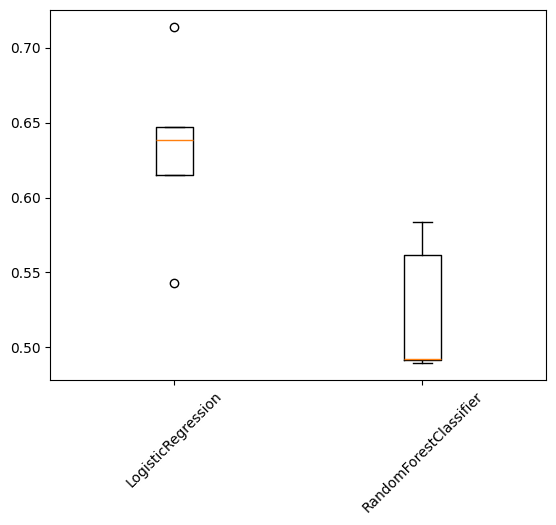

In [87]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline

logreg = LogisticRegression(max_iter=5000)
rf = RandomForestClassifier(class_weight='balanced')

models = {
    "LogisticRegression": Pipeline([
        ("smote", SMOTE(sampling_strategy="minority", random_state=42)),
        ("scaler", StandardScaler()),
        ("model", logreg)
    ]),
    "RandomForestClassifier":Pipeline([
        ("smote", SMOTE(sampling_strategy="minority", random_state=42)),
        ("model", rf)
    ])
}

results = []

sf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in models.items():
    cv_results = cross_val_score(model, X_train, y_train, cv=sf,scoring='f1_macro')
    print(f"{name}: The F1-Macro Mean is: {cv_results.mean()}, the F1-Macro Standard Deviation is: {cv_results.std()}")
    results.append(cv_results)

plt.boxplot(results, labels=models.keys())
plt.xticks(rotation=45)
plt.show()

### Hyper Parameter Tuning

In [88]:
pipeline = Pipeline([
    ("smote", SMOTE(sampling_strategy="minority", random_state=42)),
    (("scaler", StandardScaler())),
    ("model", LogisticRegression(max_iter=5000))
])

params = [{
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__class_weight": [None, "balanced"]
}]

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1                  
)

grid_search.fit(X_train, y_train)

best_estimator = grid_search.best_estimator_
y_pred = best_estimator.predict(X_test)


print("Best GridSearch Score:", best_estimator.score(X_test, y_test))

/home/duc/Documents/Python Projects/Satisfaction Prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/duc/Documents/Python Projects/Satisfaction Prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/duc/Documents/Python Projects/Satisfaction Prediction/.venv/lib/python3.12/site-packages/sklearn

Best GridSearch Score: 0.9398496240601504


/home/duc/Documents/Python Projects/Satisfaction Prediction/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
60 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "/home/duc/Documents/Python Projects/Satisfaction Prediction/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/duc/Documents/Python Projects/Satisfaction Prediction/.venv/lib/python3.12/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^

## **Evaluation**

In [89]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.20      0.56      0.29         9
         1.0       0.99      0.95      0.97       390

    accuracy                           0.94       399
   macro avg       0.59      0.75      0.63       399
weighted avg       0.97      0.94      0.95       399



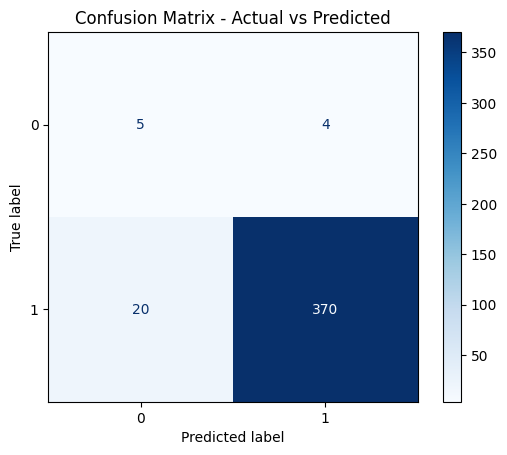

In [90]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix - Actual vs Predicted")

plt.show()

## **Schlussfolgerung**

### Modellergebnisse
Das trainierte Modell zeigt eine stark asymmetrische Vorhersageleistung. Für die Mehrheitsklasse (zufrieden) erreicht es eine Precision von 99% und einen Recall von 95%, was auf eine zuverlässige Erkennung positver Fälle hindeutet. Die Minderheitsklasse (nicht zu frieden) hingegen wird mit einer Precision von lediglich 20% und einem Recall von 56% sehr schlecht erkannt, das Modell klassifiziert die meisten unzufriedenen Gäste fälschlicherweise als zufrieden. Die hohe Gesamtgenauigkeit von 94% ist daher irreführend und spiegelt nicht die tatsächliche Modellqualität wider.

### Ursachenanalyse
Die schwache Leistung bei Klasse 0 ist primär auf den stark unbalancierten Datensatz zurückzuführen:
Von 2477 Einträgen gehören nur 46 der Minderheitsklasse an. Obwohl SMOTE eingesetzt wurde, konnte die Methode das Problem nicht beheben. Der Grund liegt darin, dass SMOTE synthetische Samples durch Interpolation zwischen bestehenden Minoritätspunkten erzeugt, bei nur 46 realen Datenpunkten ist die strukturelle Vielfalt zu gering, dass die generierten Samples kaum neue Informationen einbringen und das Modell die Klasse 0 dennoch nicht zuverlässig erlernen kann. Erschwerend kommt hinzu, dass im Testset nur 9 Samples der Klasse 0 vorhanden waren, was eine statistische Evaluierung unmöglich macht.

### Ausblick & Handlungsempfehlung
Das grundlegende Problem ist struktureller Natur:
An einem gut bewerteten Flughafen überwiegt die Zufriedenheit naturgemäß, weshalb unzufriedene Gäste immer eine kleine Minderheit darstellen werden. Dies macht einen balancierten Datensatz in der Praxis schwer erreichbar.
Folgende Maßnahmen könnten die Modellqualität künftig verbesser:
- mehr Daten erheben: Insbesondere von unzufriedenen Gästen, z.B. Beschwerdekanäle

- Alternative Sampling-Strategien: Kombination aus SMOTE und Undersampling